# MercadoLibre — Data Scientist Technical Challenge
## Detección de fraude en transacciones de pago

**Objetivo del negocio:** entrenar un modelo que decida, para cada transacción,
si **aprobarla** o **bloquearla**, de forma que se **maximice la ganancia
esperada**, sabiendo que:

- Aprobar una transacción **legítima** genera una ganancia del **25%** de su monto.
- Aprobar una transacción **fraudulenta** genera una pérdida del **100%** de su monto.
- Bloquear una transacción no genera ni ganancia ni pérdida (se asume neutro).

Este notebook cubre: carga y exploración de datos, feature engineering,
entrenamiento de modelos, y selección del umbral de decisión que maximiza
la ganancia (no simplemente accuracy/F1).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

#RAW_PATH = "MercadoLibre_Data_Scientist_Technical_Challenge_-_Dataset.csv" 
RAW_PATH = "C:/Users/jpsol/Downloads/Juan Pablo/Mercado libre/MercadoLibre Data Scientist Technical Challenge - Dataset.csv"  # ajustar path


## 1. Carga y exploración inicial (EDA)

Las columnas están anonimizadas (`a`...`p`), salvo `fecha`, `monto`, `score`
(probablemente el score de riesgo del sistema actual) y `fraude` (target).


In [8]:
df = pd.read_csv(RAW_PATH, parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)
print(df.shape)
df.head()


(150000, 19)


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.7388,6314.50,14.0,0.139279,24.0,BR,7,cat_381751d,0.937548,2361.0,442.0,1,NaN,Y,2020-03-08 00:02:15,22.18,25,0
1,4,0.7548,21171.09,20.0,0.514815,7.0,BR,2,cat_a024847,0.791998,2324.0,73.0,1,NaN,N,2020-03-08 00:04:25,6.00,7,0
2,4,0.9026,4012.83,50.0,0.274167,1.0,BR,3,cat_1d61c62,0.688592,235.0,232.0,1,N,Y,2020-03-08 00:08:23,26.67,91,1
3,4,0.8285,99612.95,1.0,0.000000,4.0,BR,28,cat_01a1725,0.654161,658.0,0.0,1,N,N,2020-03-08 00:08:39,40.01,91,1
4,2,0.5992,53526.36,2.0,0.000000,264.0,AR,34,cat_f1e7464,0.532994,2400.0,10.0,1,NaN,N,2020-03-08 00:09:01,6.25,93,0


### 1.1. Panorama General 

In [14]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Duplicados exactos:", df.duplicated().sum())
print("Rango de fechas:", df.fecha.min(), "->", df.fecha.max())

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "fraude"]
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("\nNuméricas:", num_cols)
print("Categóricas:", cat_cols)

Shape: (150000, 19)

a                  int64
b                float64
c                float64
d                float64
e                float64
f                float64
g                 object
h                  int64
j                 object
k                float64
l                float64
m                float64
n                  int64
o                 object
p                 object
fecha     datetime64[ns]
monto            float64
score              int64
fraude             int64
dtype: object

Duplicados exactos: 0
Rango de fechas: 2020-03-08 00:02:15 -> 2020-04-21 23:59:56

Numéricas: ['a', 'b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'n', 'monto', 'score']
Categóricas: ['g', 'j', 'o', 'p']


In [15]:
print("Tasa de fraude global:")
print(df["fraude"].value_counts(normalize=True))


Tasa de fraude global:
fraude
0    0.95
1    0.05
Name: proportion, dtype: float64



== Distribución del target ==
fraude
0    142500
1      7500
Name: count, dtype: int64
fraude
0    0.95
1    0.05
Name: proportion, dtype: float64


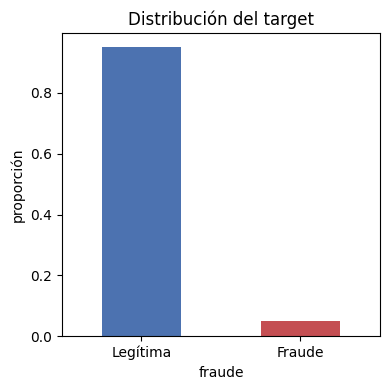

In [18]:
print("\n== Distribución del target ==")
print(df["fraude"].value_counts())
print(df["fraude"].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(4, 4))
df["fraude"].value_counts(normalize=True).plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legítima", "Fraude"], rotation=0)
ax.set_ylabel("proporción")
ax.set_title("Distribución del target")
plt.tight_layout()
plt.show()


**Desbalance de clases:** ~5% de las transacciones son fraude. Esto es
esperable en este dominio y condiciona varias decisiones más adelante
(métricas, y sobre todo el criterio de éxito real: la ganancia, no el
accuracy).

### 1.2. Missing values: overview completo + relación con el target


== Missing values ==
   n_missing  pct_missing
o     108857    72.571333
b      12984     8.656000
c      12984     8.656000
d        365     0.243333
m        365     0.243333
g        194     0.129333
f         11     0.007333
l         11     0.007333


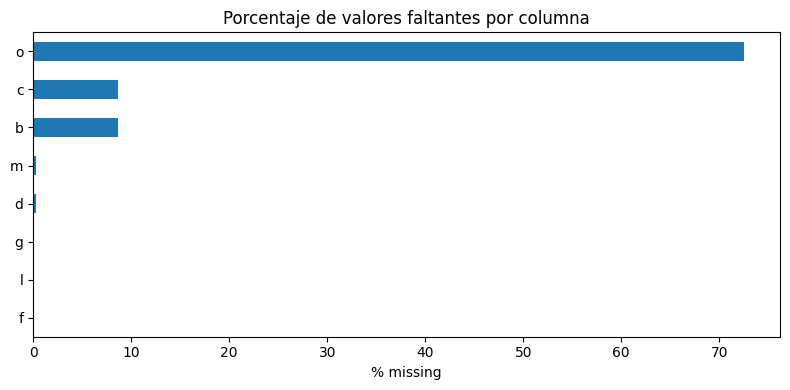


== Tasa de fraude: valor presente vs. faltante, por columna ==
  columna  fraude_si_falta  fraude_si_presente     ratio
6       f         0.000000            0.050004  0.000000
7       l         0.000000            0.050004  0.000000
0       o         0.020550            0.127920  0.160647
1       b         0.063848            0.048688  1.311373
2       c         0.063848            0.048688  1.311373
5       g         0.077320            0.049965  1.547487
3       d         0.079452            0.049928  1.591328
4       m         0.079452            0.049928  1.591328


In [17]:
miss = df.isna().sum().to_frame("n_missing")
miss["pct_missing"] = 100 * miss["n_missing"] / len(df)
miss = miss[miss["n_missing"] > 0].sort_values("pct_missing", ascending=False)
print("\n== Missing values ==")
print(miss)

fig, ax = plt.subplots(figsize=(8, 4))
miss["pct_missing"].sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("% missing")
ax.set_title("Porcentaje de valores faltantes por columna")
plt.tight_layout()
plt.show()

# generaliza el hallazgo de 'o': para TODAS las columnas con missing,
# ¿la tasa de fraude difiere según si el valor está presente o no?
print("\n== Tasa de fraude: valor presente vs. faltante, por columna ==")
rows = []
for col in miss.index:
    g = df.assign(_miss=df[col].isna()).groupby("_miss")["fraude"].mean()
    rows.append({
        "columna": col,
        "fraude_si_falta": g.get(True, np.nan),
        "fraude_si_presente": g.get(False, np.nan),
        "ratio": g.get(True, np.nan) / g.get(False, np.nan) if g.get(False, 0) else np.nan,
    })
missing_vs_fraud = pd.DataFrame(rows).sort_values("ratio")
print(missing_vs_fraud)

**Missing values:** varias columnas tienen nulos. Lo interesante es que en
algunas, la *ausencia del dato* está correlacionada con el fraude (como con la columna `o`) — es decir,
el hecho de que el campo no esté poblado es, en sí mismo, información
(probablemente porque ese campo lo completa un sistema/regla que no se
dispara para todas las transacciones).
Pero `o` no es binaria: cuando tiene valor, puede ser "Y" o "N". Vale la
pena desagregar en las 3 categorías reales (`Y`, `N`, ausente) antes de
decidir cómo codificarla, porque un solo flag "está presente / no está
presente" puede estar escondiendo algo más fuerte todavía.

In [28]:
print(df["o"].value_counts(dropna=False, normalize=True))
print()
print(df.groupby(df["o"].fillna("MISSING"))["fraude"].mean())

o
NaN    0.725713
Y      0.160607
N      0.113680
Name: proportion, dtype: float64

o
MISSING    0.020550
N          0.217511
Y          0.064505
Name: fraude, dtype: float64


### 1.3. Numéricas: estadísticos descriptivos generales y por clase


== describe() general ==
          count           mean            std       min          25%   
a      150000.0       3.705407       0.753206  1.000000     4.000000  \
b      137016.0       0.728115       0.132943  0.000000     0.678400   
c      137016.0  260445.107044  846436.141626  0.160000  9679.915000   
d      149635.0      21.677669      20.062146  0.000000     2.000000   
e      150000.0       0.220641       2.434995  0.000000     0.000000   
f      149989.0      51.169352     709.472904 -5.000000     1.000000   
h      150000.0      14.193513      14.161216  0.000000     3.000000   
k      150000.0       0.497532       0.288348  0.000004     0.246819   
l      149989.0    2305.409403    1712.379601  0.000000   910.000000   
m      149635.0     299.969579     321.075806  0.000000    42.000000   
n      150000.0       0.902353       0.296837  0.000000     1.000000   
monto  150000.0      43.523134      91.557888  0.020000     9.380000   
score  150000.0      48.066240      28

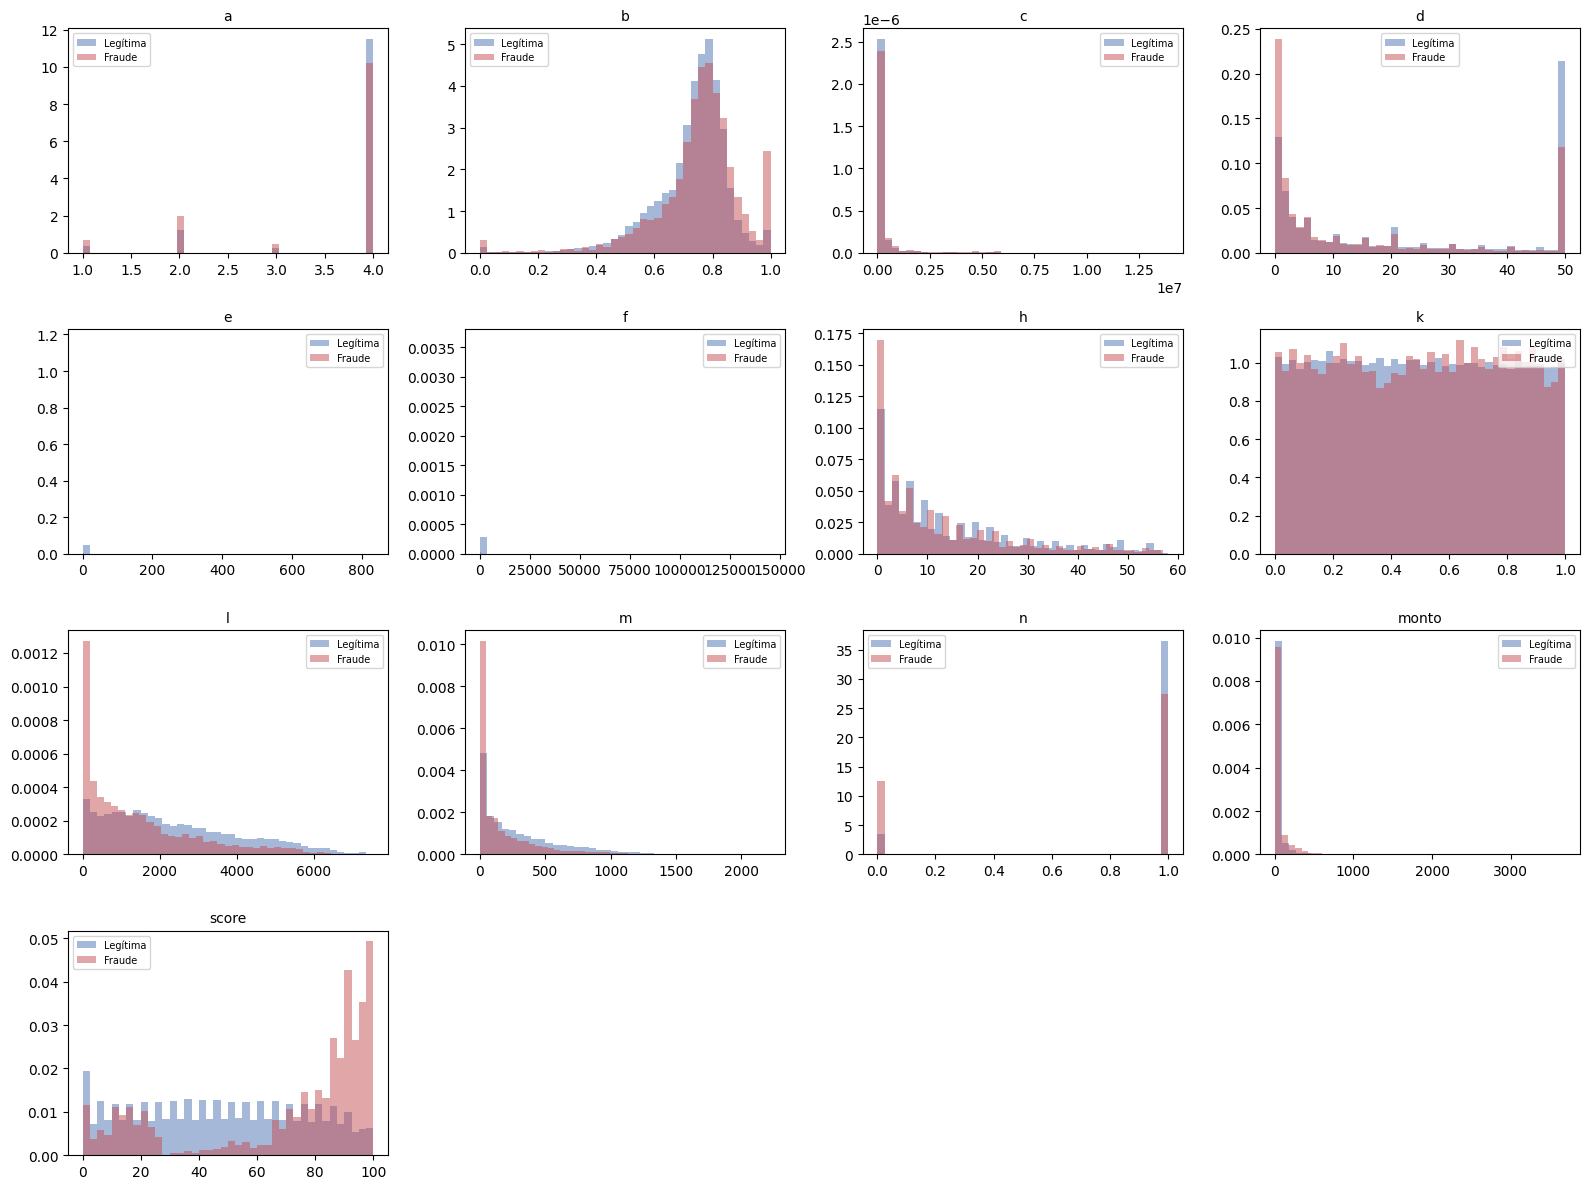

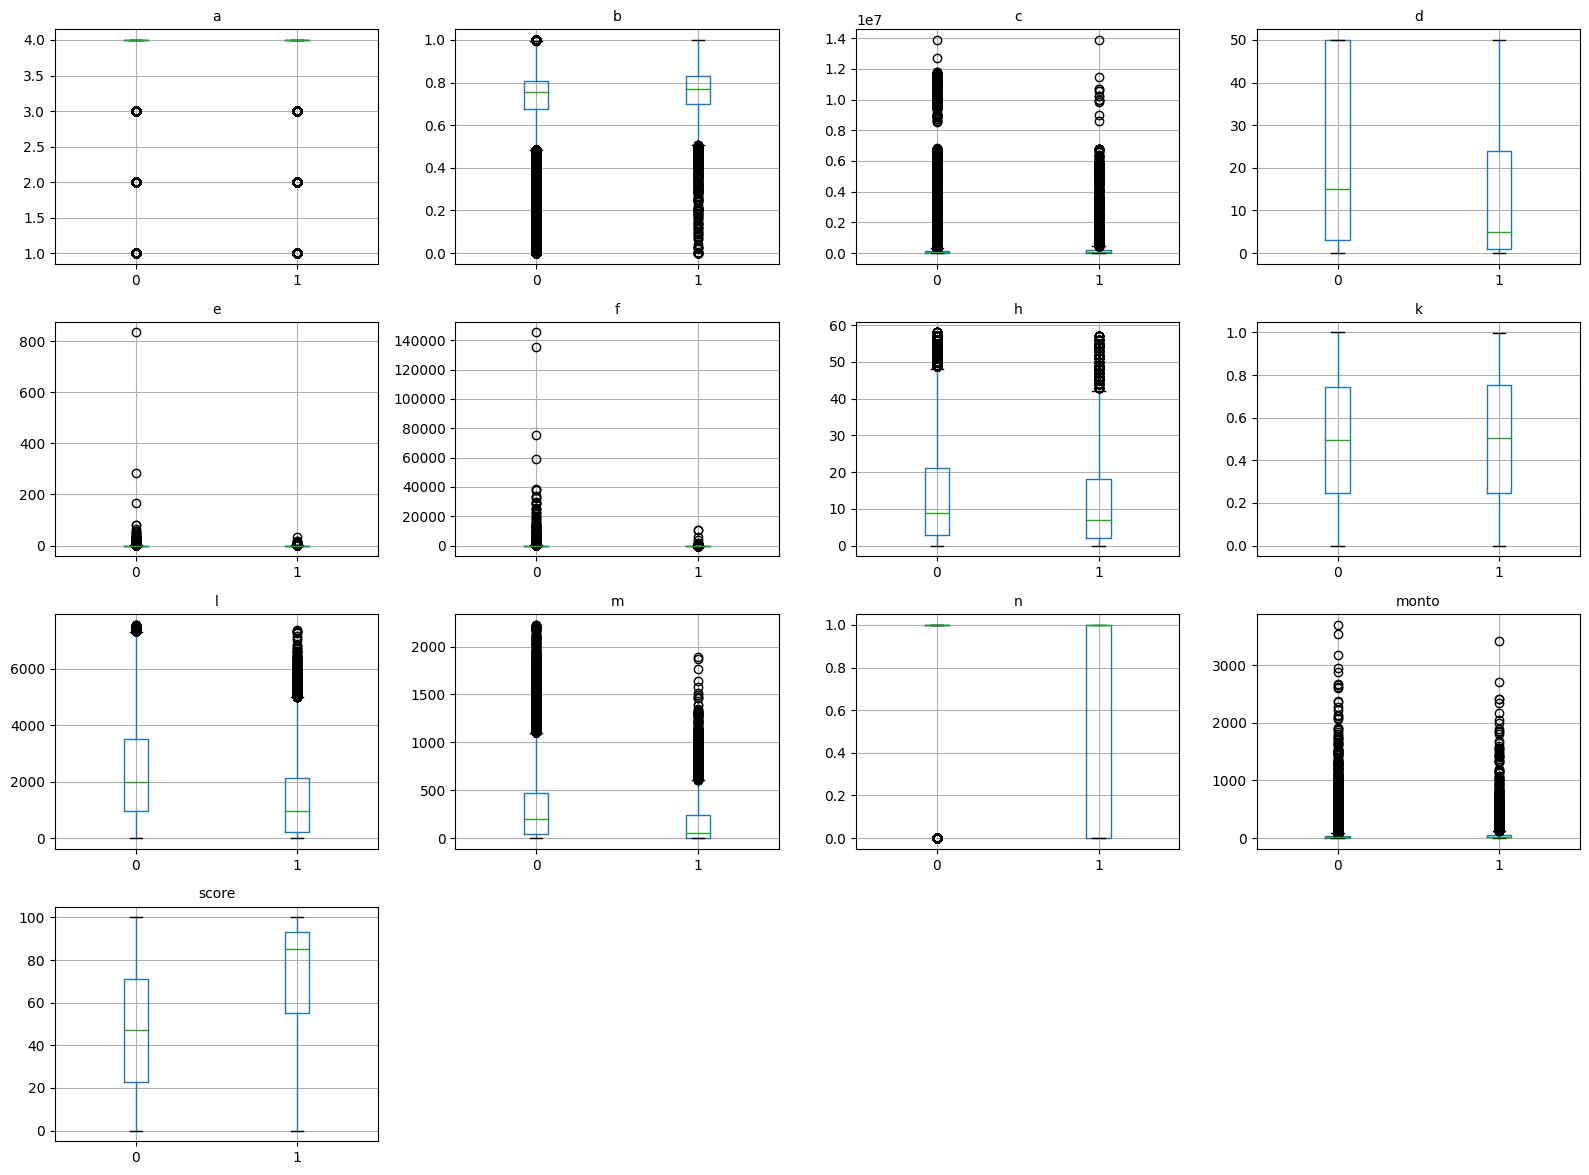

In [19]:
print("\n== describe() general ==")
print(df[num_cols].describe().T)

print("\n== describe() por clase (medias) ==")
print(df.groupby("fraude")[num_cols].mean().T)

# histogramas de todas las numéricas, separadas por clase
n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    for label, name, color in [(0, "Legítima", "#4C72B0"), (1, "Fraude", "#C44E52")]:
        vals = df.loc[df["fraude"] == label, col].dropna()
        ax.hist(vals, bins=40, alpha=0.5, density=True, label=name, color=color)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# boxplots (detección de outliers / escala) - cada var con su propia escala
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by="fraude", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("")
plt.tight_layout()
plt.show()


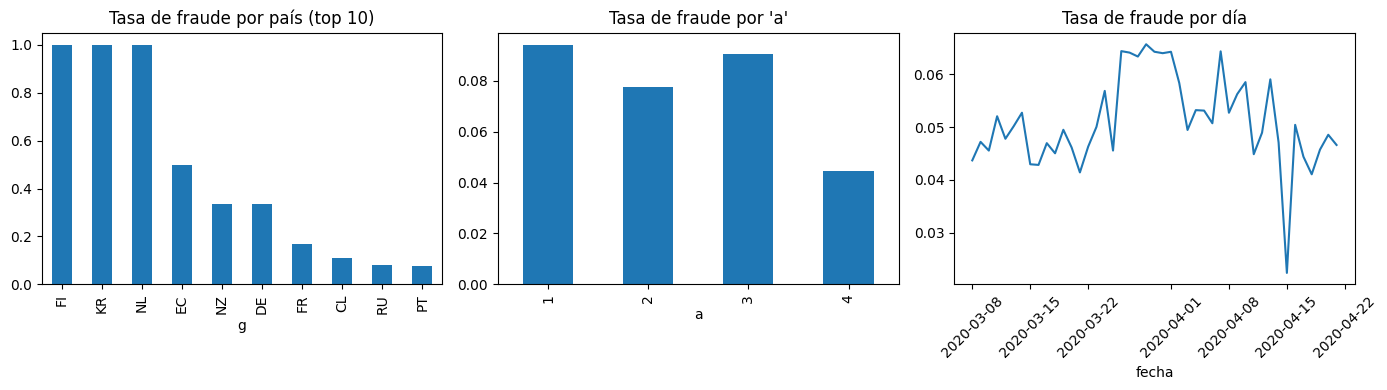

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df.groupby("g")["fraude"].mean().sort_values(ascending=False).head(10).plot(kind="bar", ax=axes[0], title="Tasa de fraude por país (top 10)")
df.groupby("a")["fraude"].mean().plot(kind="bar", ax=axes[1], title="Tasa de fraude por 'a'")
df.groupby(df.fecha.dt.date)["fraude"].mean().plot(ax=axes[2], title="Tasa de fraude por día", rot=45)
plt.tight_layout()
plt.show()


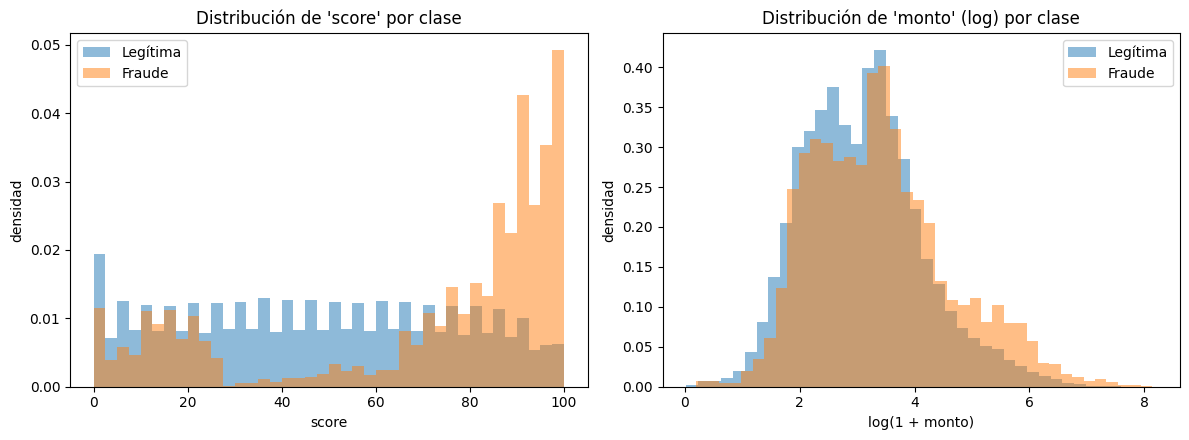

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label, name in [(0, "Legítima"), (1, "Fraude")]:
    subset = df.loc[df["fraude"] == label, "score"]
    axes[0].hist(subset, bins=40, alpha=0.5, density=True, label=name)
axes[0].set_xlabel("score"); axes[0].set_ylabel("densidad")
axes[0].set_title("Distribución de 'score' por clase")
axes[0].legend()

for label, name in [(0, "Legítima"), (1, "Fraude")]:
    subset = np.log1p(df.loc[df["fraude"] == label, "monto"])
    axes[1].hist(subset, bins=40, alpha=0.5, density=True, label=name)
axes[1].set_xlabel("log(1 + monto)"); axes[1].set_ylabel("densidad")
axes[1].set_title("Distribución de 'monto' (log) por clase")
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.4. Detección automática de valores centinela / sospechosos
(heurística: un único valor concentra una fracción grande de la columna, lo que sugiere un código especial en vez de una medición)

In [21]:
print("\n== Posibles valores centinela (un valor puntual con alta concentración) ==")
for col in num_cols:
    vc = df[col].value_counts(normalize=True, dropna=True)
    if len(vc) == 0:
        continue
    top_val, top_pct = vc.index[0], vc.iloc[0]
    if top_pct > 0.02:  # más del 2% de las filas comparten exactamente el mismo valor
        fraud_rate_at_val = df.loc[df[col] == top_val, "fraude"].mean()
        print(f"{col:6s}: valor {top_val!r:>12} concentra {top_pct*100:5.1f}% de las filas "
              f"| tasa de fraude en ese subconjunto: {fraud_rate_at_val:.3f} (global {df.fraude.mean():.3f})")

print("\n== Rango (min/max) de cada numérica, para detectar negativos/valores fuera de rango ==")
print(df[num_cols].agg(["min", "max"]).T)


== Posibles valores centinela (un valor puntual con alta concentración) ==
a     : valor            4 concentra  85.7% de las filas | tasa de fraude en ese subconjunto: 0.045 (global 0.050)
d     : valor         50.0 concentra  25.8% de las filas | tasa de fraude en ese subconjunto: 0.028 (global 0.050)
e     : valor          0.0 concentra  43.4% de las filas | tasa de fraude en ese subconjunto: 0.056 (global 0.050)
f     : valor          0.0 concentra  16.9% de las filas | tasa de fraude en ese subconjunto: 0.115 (global 0.050)
h     : valor            0 concentra   8.6% de las filas | tasa de fraude en ese subconjunto: 0.090 (global 0.050)
m     : valor          0.0 concentra  10.6% de las filas | tasa de fraude en ese subconjunto: 0.117 (global 0.050)
n     : valor            1 concentra  90.2% de las filas | tasa de fraude en ese subconjunto: 0.038 (global 0.050)
score : valor            0 concentra   3.3% de las filas | tasa de fraude en ese subconjunto: 0.030 (global 0.050)

== 

**Otras señales encontradas en el EDA**

- `f` tiene un valor centinela **-5** (imposible / "no aplica") en ~0.85% de las filas.
- `e` tiene una masa grande de ceros exactos (~43%), probablemente "sin actividad previa".
- `d` está topeado en **50** (~26% de las filas) — variable censurada/capada.
- `k` se ve como ruido casi uniforme entre 0 y 1, con poca diferencia de medias entre clases.
- `score` (el score de riesgo del sistema actual) y `monto` están claramente más
  altos, en promedio, para las transacciones fraudulentas.

Todo esto se traduce en el feature engineering de la siguiente sección.


### 1.5. Categóricas: cardinalidad, top categorías y tasa de fraude


== g ==
cardinalidad: 51 | % missing: 0.13
    pct_filas  tasa_fraude
g                         
BR   0.745150     0.055201
AR   0.213369     0.036885
UY   0.019806     0.009774
US   0.015173     0.030796
SE   0.002390     0.041899
MX   0.001575     0.012712
RU   0.000487     0.082192
ES   0.000461     0.072464
CO   0.000427     0.015625
GB   0.000287     0.000000

== j ==
cardinalidad: 8324 | % missing: 0.0
             pct_filas  tasa_fraude
j                                  
cat_43b9c10   0.015540     0.163020
cat_d69bed9   0.011993     0.030017
cat_604df77   0.011893     0.039798
cat_6c4cfdc   0.009660     0.051070
cat_4249bd8   0.007940     0.082284
cat_3203c7c   0.007287     0.017383
cat_be0af8e   0.006933     0.050000
cat_0820fab   0.006253     0.051173
cat_8ef7164   0.006060     0.089109
cat_d5975ae   0.005853     0.068337

== o ==
cardinalidad: 2 | % missing: 72.57
   pct_filas  tasa_fraude
o                        
Y   0.585543     0.064505
N   0.414457     0.217511

== p =

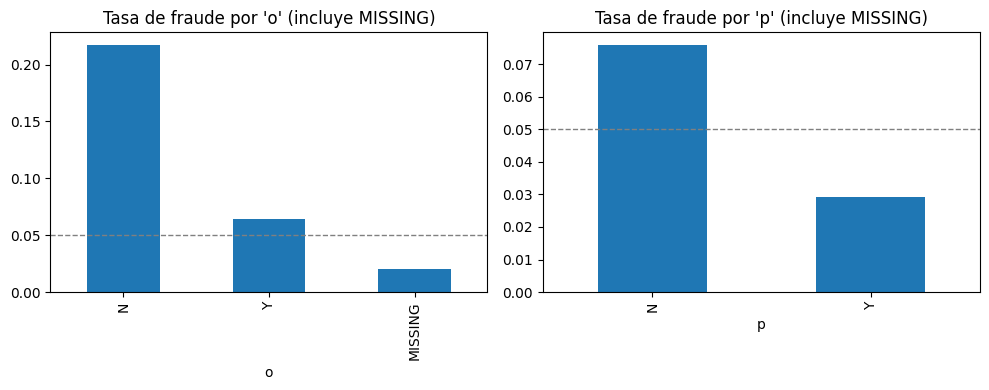

In [22]:
for col in cat_cols:
    print(f"\n== {col} ==")
    print("cardinalidad:", df[col].nunique(dropna=True), "| % missing:", round(100 * df[col].isna().mean(), 2))
    top = df[col].value_counts(normalize=True).head(10)
    fraud_rate = df.groupby(col)["fraude"].mean().reindex(top.index)
    summary = pd.DataFrame({"pct_filas": top, "tasa_fraude": fraud_rate})
    print(summary)

# categóricas de baja cardinalidad: graficar directo (incluye NaN como categoría)
low_card_cats = [c for c in cat_cols if df[c].nunique() <= 15]
fig, axes = plt.subplots(1, len(low_card_cats), figsize=(5 * len(low_card_cats), 4))
if len(low_card_cats) == 1:
    axes = [axes]
for ax, col in zip(axes, low_card_cats):
    df.assign(**{col: df[col].fillna("MISSING")}).groupby(col)["fraude"].mean() \
        .sort_values(ascending=False).plot(kind="bar", ax=ax)
    ax.set_title(f"Tasa de fraude por '{col}' (incluye MISSING)")
    ax.axhline(df.fraude.mean(), color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

### 1.6. Correlación entre numéricas (y con el target)

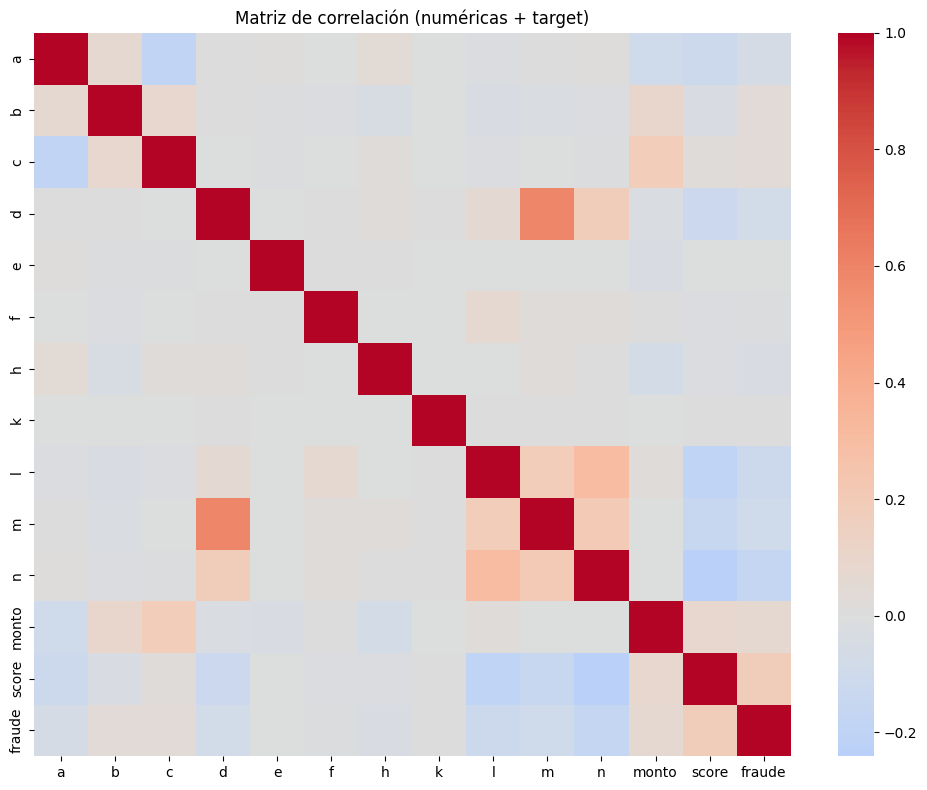


== Correlación de cada numérica con 'fraude' (ordenada por |correlación|) ==
score    0.172737
n       -0.167728
l       -0.117023
m       -0.093437
d       -0.077807
monto    0.073784
a       -0.059681
b        0.038919
h       -0.034864
c        0.033229
f       -0.010489
k        0.002395
e       -0.002261
Name: fraude, dtype: float64


In [ ]:
corr = df[num_cols + ["fraude"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Matriz de correlación (numéricas + target)")
plt.tight_layout()
plt.show()

print("\n== Correlación de cada numérica con 'fraude' (ordenada por |correlación|) ==")
print(corr["fraude"].drop("fraude").sort_values(key=abs, ascending=False))

### 1.7 Series temporales: tasa de fraude y volumen por día / hora / día de semana

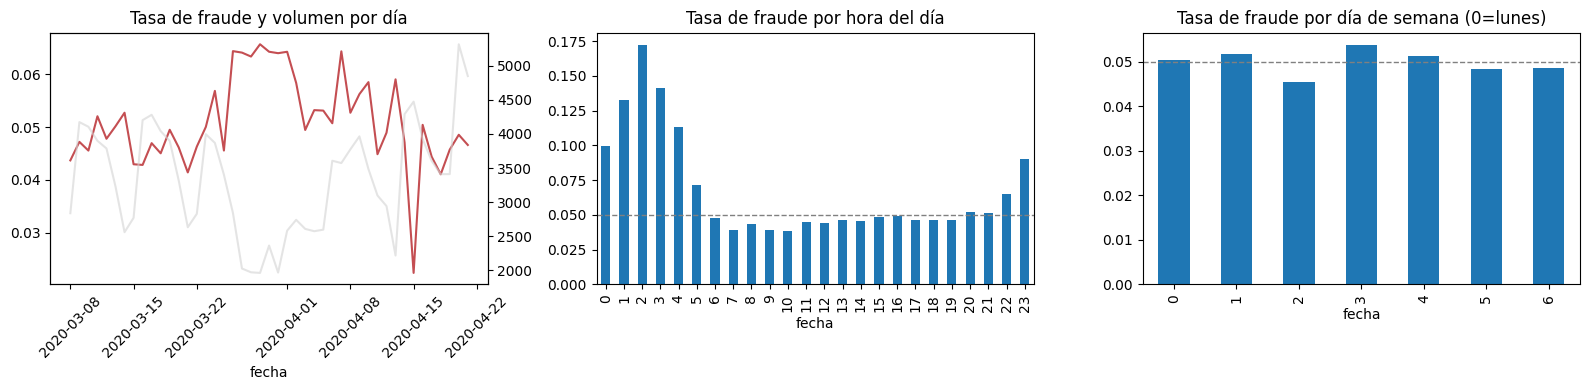

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

daily = df.groupby(df.fecha.dt.date).agg(tasa_fraude=("fraude", "mean"), volumen=("fraude", "size"))
ax2 = axes[0].twinx()
daily["volumen"].plot(ax=ax2, color="lightgray", alpha=0.6, label="volumen")
daily["tasa_fraude"].plot(ax=axes[0], color="#C44E52", label="tasa fraude")
axes[0].set_title("Tasa de fraude y volumen por día")
axes[0].tick_params(axis="x", rotation=45)

df.groupby(df.fecha.dt.hour)["fraude"].mean().plot(kind="bar", ax=axes[1])
axes[1].axhline(df.fraude.mean(), color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Tasa de fraude por hora del día")

df.groupby(df.fecha.dt.dayofweek)["fraude"].mean().plot(kind="bar", ax=axes[2])
axes[2].axhline(df.fraude.mean(), color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Tasa de fraude por día de semana (0=lunes)")

plt.tight_layout()
plt.show()

### 1.8. Relación bivariada score vs. monto, coloreada por clase
(muestreo para que el scatter no sea ilegible con 150k puntos)

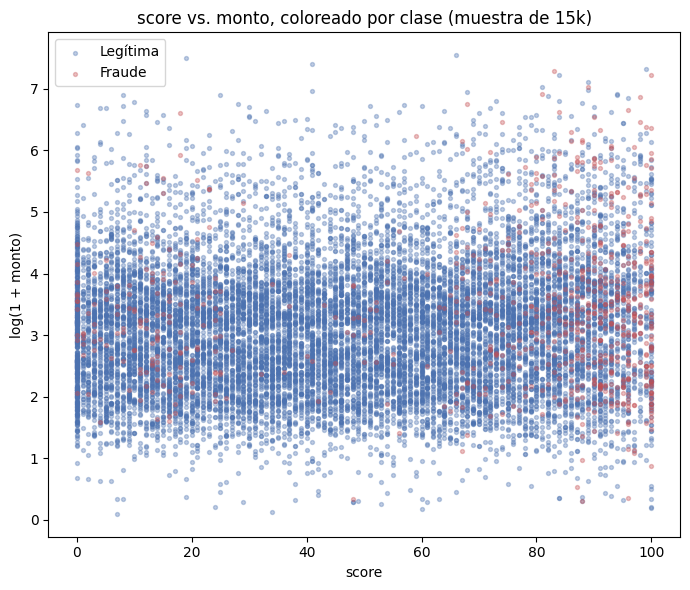

In [26]:
sample = df.sample(15000, random_state=42)
fig, ax = plt.subplots(figsize=(7, 6))
for label, name, color in [(0, "Legítima", "#4C72B0"), (1, "Fraude", "#C44E52")]:
    s = sample[sample["fraude"] == label]
    ax.scatter(s["score"], np.log1p(s["monto"]), s=8, alpha=0.35, label=name, color=color)
ax.set_xlabel("score")
ax.set_ylabel("log(1 + monto)")
ax.set_title("score vs. monto, coloreado por clase (muestra de 15k)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Split temporal (train / validation / test)

**Por qué temporal y no aleatorio:** en producción el modelo siempre va a
predecir sobre transacciones *futuras* respecto a los datos con los que fue
entrenado. Un split aleatorio mezclaría información del futuro en el
entrenamiento (aunque no haya leakage de columnas, sí hay leakage temporal:
patrones estacionales, campañas de fraude que aparecen y desaparecen, drift
del propio sistema de scoring). Separar por fecha es la forma más realista
de estimar cómo se va a comportar el modelo el día que lo pongamos en
producción.

Usamos:
- **Train** (70%): para ajustar los modelos.
- **Validation** (15%, posterior a train): para elegir el umbral de decisión
  que maximiza la ganancia.
- **Test** (15%, el más reciente): holdout final, simula "producción".


In [27]:
def temporal_split(df, val_frac=0.15, test_frac=0.15):
    train_cut = df["fecha"].quantile(1 - val_frac - test_frac)
    val_cut = df["fecha"].quantile(1 - test_frac)
    train = df[df["fecha"] <= train_cut].copy()
    val = df[(df["fecha"] > train_cut) & (df["fecha"] <= val_cut)].copy()
    test = df[df["fecha"] > val_cut].copy()
    return train, val, test

train_raw, val_raw, test_raw = temporal_split(df)
for name, d in [("train", train_raw), ("val", val_raw), ("test", test_raw)]:
    print(f"{name:5s}: {len(d):>7,} filas | {d.fecha.min()} -> {d.fecha.max()} | tasa fraude={d.fraude.mean():.4f}")


train: 105,000 filas | 2020-03-08 00:02:15 -> 2020-04-10 00:12:50 | tasa fraude=0.0518
val  :  22,500 filas | 2020-04-10 00:12:58 -> 2020-04-16 14:50:10 | tasa fraude=0.0453
test :  22,500 filas | 2020-04-16 14:51:15 -> 2020-04-21 23:59:56 | tasa fraude=0.0460


## 3. Feature engineering

Principios aplicados:

1. **La ausencia de dato es una señal**: se agregan flags `*_missing`. Para
   `o` en particular (73% missing) esto no alcanza: tiene 3 estados con
   tasas de fraude muy distintas (`Y`=6.5%, `N`=21.8%, ausente=2.1%), así
   que se codifica como categórica de 3 niveles en vez de un flag binario,
   para no mezclar `N` y "ausente" en el mismo bucket.
2. **Los valores centinela se separan explícitamente** (`f == -5`, `e == 0`,
   `d == 50`) para que el modelo pueda tratarlos como una categoría aparte en
   vez de como un valor numérico más en la escala continua.
3. **Todo estadístico (medianas, frecuencias de categoría) se calcula
   *solo* con el fold de train** y se aplica igual a validation/test. Esto
   evita leakage y es indispensable para que las métricas offline sean
   representativas de lo que vamos a ver en producción.
4. **`j` (categoría de producto, ~8.300 valores únicos)** se codifica por
   frecuencia (conteo en train) en lugar de one-hot, para no explotar la
   dimensionalidad ni fragmentar el árbol en categorías con 1-2 casos.
5. **`monto` y `c`** se transforman con `log1p` por su fuerte asimetría.


In [29]:
class FeatureBuilder:
    """Ajusta estadísticos SOLO sobre el fold de train (fit) y los aplica
    igual a cualquier fold (transform), evitando leakage temporal/de fold."""

    def __init__(self, top_countries=8, min_freq_j=20):
        self.top_countries = top_countries
        self.min_freq_j = min_freq_j

    def fit(self, X):
        self.top_g_ = X["g"].value_counts().nlargest(self.top_countries).index.tolist()
        self.j_freq_ = X["j"].value_counts().to_dict()
        self.b_median_, self.c_median_ = X["b"].median(), X["c"].median()
        self.d_median_, self.f_median_ = X["d"].median(), X["f"].median()
        self.l_median_, self.m_median_ = X["l"].median(), X["m"].median()
        return self

    def transform(self, X):
        X = X.copy()

        # calendario
        X["hour"] = X["fecha"].dt.hour
        X["dow"] = X["fecha"].dt.dayofweek
        X["is_weekend"] = X["dow"].isin([5, 6]).astype(int)

        # missingness como señal
        for col in ["b", "c", "d", "f", "l", "m", "g"]:
            X[f"{col}_missing"] = X[col].isna().astype(int)
        X["o_cat"] = X["o"].fillna("MISSING")
        X["p_is_Y"] = (X["p"] == "Y").astype(int)

        # valores centinela detectados en el EDA
        X["f_is_sentinel"] = (X["f"] == -5).astype(int)
        X["e_is_zero"] = (X["e"] == 0).astype(int)
        X["d_is_capped"] = (X["d"] == 50).astype(int)

        # imputación con medianas de TRAIN
        X["b_imp"] = X["b"].fillna(self.b_median_)
        X["c_imp"] = X["c"].fillna(self.c_median_)
        X["d_imp"] = X["d"].fillna(self.d_median_)
        X["f_imp"] = X["f"].fillna(self.f_median_)
        X["l_imp"] = X["l"].fillna(self.l_median_)
        X["m_imp"] = X["m"].fillna(self.m_median_)

        # corrección de asimetría
        X["monto_log"] = np.log1p(X["monto"])
        X["c_log"] = np.log1p(X["c_imp"].clip(lower=0))

        # categóricas
        X["g_grouped"] = np.where(X["g"].isin(self.top_g_), X["g"], "OTHER")
        X["g_grouped"] = X["g_grouped"].fillna("MISSING")
        X["j_freq"] = X["j"].map(self.j_freq_).fillna(0)
        X["j_is_rare"] = (X["j_freq"] < self.min_freq_j).astype(int)
        X["a_cat"] = X["a"].astype(str)

        num_cols = [
            "b_imp", "c_log", "d_imp", "e", "f_imp", "h", "k", "l_imp", "m_imp",
            "monto_log", "score", "j_freq", "hour", "dow", "is_weekend",
            "b_missing", "c_missing", "d_missing", "f_missing", "l_missing", "m_missing",
            "g_missing", "p_is_Y", "f_is_sentinel", "e_is_zero",
            "d_is_capped", "j_is_rare", "n",
        ]
        cat_cols = ["g_grouped", "a_cat", "o_cat"]
        return X, num_cols, cat_cols


fb = FeatureBuilder().fit(train_raw)
train_fe, num_cols, cat_cols = fb.transform(train_raw)
val_fe, _, _ = fb.transform(val_raw)
test_fe, _, _ = fb.transform(test_raw)

train_dum = pd.get_dummies(train_fe[cat_cols], prefix=cat_cols)
val_dum = pd.get_dummies(val_fe[cat_cols], prefix=cat_cols).reindex(columns=train_dum.columns, fill_value=0)
test_dum = pd.get_dummies(test_fe[cat_cols], prefix=cat_cols).reindex(columns=train_dum.columns, fill_value=0)

def assemble(fe, dum):
    X = pd.concat([fe[num_cols].reset_index(drop=True), dum.reset_index(drop=True)], axis=1)
    return X, fe["fraude"].reset_index(drop=True), fe["monto"].reset_index(drop=True)

X_train, y_train, monto_train = assemble(train_fe, train_dum)
X_val, y_val, monto_val = assemble(val_fe, val_dum)
X_test, y_test, monto_test = assemble(test_fe, test_dum)

print(X_train.shape, X_val.shape, X_test.shape)
X_train.head()

(105000, 44) (22500, 44) (22500, 44)


,b_imp,c_log,d_imp,e,f_imp,h,k,l_imp,m_imp,monto_log,score,j_freq,hour,dow,is_weekend,b_missing,c_missing,d_missing,f_missing,l_missing,m_missing,g_missing,p_is_Y,f_is_sentinel,e_is_zero,d_is_capped,j_is_rare,n,g_grouped_AR,g_grouped_BR,g_grouped_CO,g_grouped_MX,g_grouped_OTHER,g_grouped_RU,g_grouped_SE,g_grouped_US,g_grouped_UY,a_cat_1,a_cat_2,a_cat_3,a_cat_4,o_cat_MISSING,o_cat_N,o_cat_Y
0,0.7388,8.750762,14.0,0.139279,24.0,7,0.937548,2361.0,442.0,3.143290,25,479,0,6,1,0,0,0,0,0,0,0,1,0,0,0,0,1,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,False
1,0.7548,9.960439,20.0,0.514815,7.0,2,0.791998,2324.0,73.0,1.945910,7,14,0,6,1,0,0,0,0,0,0,0,0,0,0,0,1,1,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,False
2,0.9026,8.297501,50.0,0.274167,1.0,3,0.688592,235.0,232.0,3.320349,91,278,0,6,1,0,0,0,0,0,0,0,1,0,0,1,0,1,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
3,0.8285,11.509057,1.0,0.000000,4.0,28,0.654161,658.0,0.0,3.713816,91,46,0,6,1,0,0,0,0,0,0,0,0,0,1,0,0,1,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
4,0.5992,10.887948,2.0,0.000000,264.0,34,0.532994,2400.0,10.0,1.981001,93,8,0,6,1,0,0,0,0,0,0,0,0,0,1,0,1,1,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False


## 4. El umbral óptimo de decisión (análisis económico)

Antes de entrenar, conviene pensar el problema como una decisión económica
en vez de una clasificación binaria estándar.

Para una transacción de monto $M$ con probabilidad estimada de fraude $p$,
el valor esperado de **aprobarla** es:

$$EV(\text{aprobar}) = (1-p)\cdot 0.25M \;-\; p \cdot 1.00M = M\,(0.25 - 1.25p)$$

Conviene aprobar mientras $EV > 0$, es decir:

$$p < \frac{0.25}{0.25 + 1.00} = 0.20$$

**Dato clave: el monto $M$ se cancela.** El umbral óptimo (20% de
probabilidad de fraude) es el mismo sin importar si la transacción es de
$10 o de $10.000 — porque tanto la ganancia como la pérdida escalan
proporcionalmente con el monto. Esto simplifica mucho la implementación: no
hace falta un umbral distinto por rango de monto.

⚠️ **Esto solo es válido si $p$ es una probabilidad bien calibrada.** Un
modelo entrenado con `class_weight="balanced"` produce scores que ordenan
bien (buen ranking) pero que ya no reflejan la probabilidad real de fraude
— están artificialmente "infladas". Por eso en la siguiente sección
comparamos el umbral analítico (0.20) contra el umbral **elegido
empíricamente sobre validación** (buscando directamente el que maximiza la
ganancia), tanto con modelos calibrados como sin calibrar.


## 5. Entrenamiento de modelos

Se comparan 3 modelos, de menor a mayor complejidad:

1. **Regresión Logística** — baseline interpretable.
2. **Random Forest** — no lineal, robusto a outliers/escala.
3. **LightGBM** — gradient boosting, generalmente el mejor punto de partida
   para datos tabulares con relaciones no lineales y variables mixtas
   (como es el caso acá). Se entrena una versión "cruda" y una **calibrada**
   (`CalibratedClassifierCV`, sigmoid) para poder usar el umbral analítico
   correctamente.

Todos se entrenan con `class_weight="balanced"` para compensar el
desbalance de clases (~5% fraude) durante el ajuste — pero, como se explicó
arriba, esto rompe la calibración de probabilidades del modelo crudo.


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import lightgbm as lgb

GAIN_RATE, LOSS_RATE = 0.25, 1.00
ANALYTIC_THR = GAIN_RATE / (GAIN_RATE + LOSS_RATE)  # 0.20

models = {}

# --- Logistic Regression ---
scaler = StandardScaler().fit(X_train)
lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(scaler.transform(X_train), y_train)
models["LogisticRegression"] = lambda X, lr=lr, sc=scaler: lr.predict_proba(sc.transform(X))[:, 1]

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=400, max_depth=10, min_samples_leaf=20,
    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
models["RandomForest"] = lambda X, rf=rf: rf.predict_proba(X)[:, 1]

# --- LightGBM (crudo) ---
lgbm = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.03, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)
lgbm.fit(X_train, y_train)
models["LightGBM"] = lambda X, m=lgbm: m.predict_proba(X)[:, 1]

# --- LightGBM calibrado ---
lgbm_cal = CalibratedClassifierCV(
    lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.03, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
        class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
    ),
    method="sigmoid", cv=3,
)
lgbm_cal.fit(X_train, y_train)
models["LightGBM_calibrated"] = lambda X, m=lgbm_cal: m.predict_proba(X)[:, 1]

print("Modelos entrenados:", list(models.keys()))


Modelos entrenados: ['LogisticRegression', 'RandomForest', 'LightGBM', 'LightGBM_calibrated']


## 6. Selección del umbral y evaluación en el holdout temporal

Para cada modelo:
1. Se busca, sobre **validation**, el umbral que maximiza la ganancia neta.
2. Se aplica ese umbral sobre **test** (el fold más reciente, nunca visto).
3. Se compara también contra el umbral analítico fijo (0.20).
4. Se compara contra dos baselines de referencia: aprobar todo / bloquear todo.


In [31]:
def profit(y_true, monto, p_fraud, threshold):
    approve = p_fraud < threshold
    is_fraud = y_true.values.astype(bool)
    return (
        GAIN_RATE * monto[approve & ~is_fraud].sum()
        - LOSS_RATE * monto[approve & is_fraud].sum()
    )

def best_threshold(y_true, monto, p_fraud, grid=None):
    grid = np.linspace(0.0, 1.0, 1001) if grid is None else grid
    profits = np.array([profit(y_true, monto, p_fraud, t) for t in grid])
    i = int(profits.argmax())
    return grid[i], profits[i], grid, profits

baseline_approve_all = profit(y_test, monto_test, np.zeros(len(y_test)), 1.0)
baseline_block_all = 0.0
print(f"Baseline aprobar todo (test): {baseline_approve_all:,.2f}")
print(f"Baseline bloquear todo (test): {baseline_block_all:,.2f}")


Baseline aprobar todo (test): 138,456.17
Baseline bloquear todo (test): 0.00


In [32]:
rows, curves = [], {}
for name, predict_fn in models.items():
    p_val, p_test = predict_fn(X_val), predict_fn(X_test)
    thr, _, grid, val_curve = best_threshold(y_val, monto_val, p_val)
    test_profit_tuned = profit(y_test, monto_test, p_test, thr)
    test_profit_analytic = profit(y_test, monto_test, p_test, ANALYTIC_THR)
    rows.append({
        "model": name,
        "auc_test": roc_auc_score(y_test, p_test),
        "ap_test": average_precision_score(y_test, p_test),
        "brier_test": brier_score_loss(y_test, p_test),
        "thr_tuned_on_val": thr,
        "test_profit_tuned_thr": test_profit_tuned,
        "test_profit_analytic_thr": test_profit_analytic,
    })
    curves[name] = (grid, val_curve, p_test)

results = pd.DataFrame(rows).sort_values("test_profit_tuned_thr", ascending=False)
results


,model,auc_test,ap_test,brier_test,thr_tuned_on_val,test_profit_tuned_thr,test_profit_analytic_thr
2,LightGBM,0.886150,0.434830,0.097540,0.755,174161.9775,116303.5075
3,LightGBM_calibrated,0.885627,0.435977,0.033854,0.197,173985.2975,174602.7175
1,RandomForest,0.872971,0.384596,0.108378,0.584,170402.0900,89865.7800
0,LogisticRegression,0.844988,0.315033,0.141050,0.803,165616.3875,76726.6950


**Lectura de la tabla:**

- Todos los modelos calibran mal cuando se usan `class_weight="balanced"`
  sin ajuste posterior — se ve en que `test_profit_analytic_thr` es mucho
  más bajo que `test_profit_tuned_thr` para los modelos crudos, y que el
  `brier_score` (error de calibración) es más alto.
- **`LightGBM_calibrated` es la excepción**: su umbral óptimo encontrado en
  validación (~0.20) coincide casi exactamente con el umbral analítico
  (0.20), y ambos dan una ganancia similar y la más alta de todos los
  modelos. Esto confirma que, una vez que las probabilidades están bien
  calibradas, la fórmula económica simple (`p < 0.20`) funciona sola —
  sin necesidad de búsqueda empírica de umbral.
- Ranking por AUC/AP también favorece a LightGBM, consistente con que suele
  ser la mejor opción para datos tabulares con relaciones no lineales.


In [33]:
best_name = results.iloc[0]["model"]
best_thr = results.iloc[0]["thr_tuned_on_val"]
p_test_best = curves[best_name][2]
print(f"Modelo elegido: {best_name} | umbral: {best_thr:.3f}")

for _, r in results.iterrows():
    uplift = r["test_profit_tuned_thr"] - baseline_approve_all
    pct = 100 * uplift / baseline_approve_all
    print(f"{r['model']:22s} ganancia={r['test_profit_tuned_thr']:>12,.2f}  uplift vs. aprobar-todo={uplift:>10,.2f} ({pct:+.1f}%)")


Modelo elegido: LightGBM | umbral: 0.755
LightGBM               ganancia=  174,161.98  uplift vs. aprobar-todo= 35,705.81 (+25.8%)
LightGBM_calibrated    ganancia=  173,985.30  uplift vs. aprobar-todo= 35,529.13 (+25.7%)
RandomForest           ganancia=  170,402.09  uplift vs. aprobar-todo= 31,945.92 (+23.1%)
LogisticRegression     ganancia=  165,616.39  uplift vs. aprobar-todo= 27,160.22 (+19.6%)


## 7. Gráficos de diagnóstico

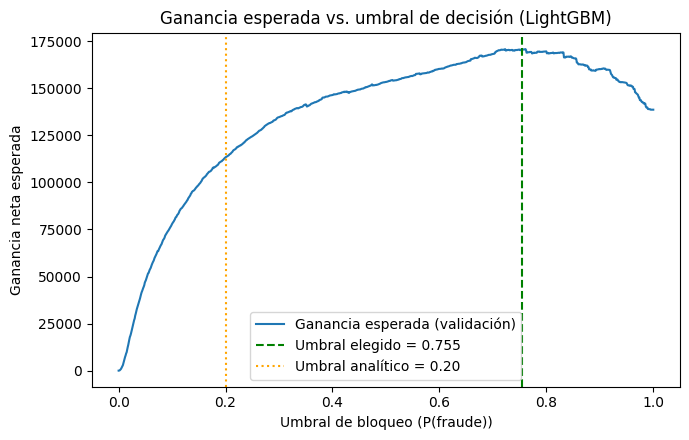

In [34]:
plt.figure(figsize=(7, 4.5))
grid_best, val_curve_best, _ = curves[best_name]
plt.plot(grid_best, val_curve_best, label="Ganancia esperada (validación)")
plt.axvline(best_thr, color="green", linestyle="--", label=f"Umbral elegido = {best_thr:.3f}")
plt.axvline(ANALYTIC_THR, color="orange", linestyle=":", label="Umbral analítico = 0.20")
plt.xlabel("Umbral de bloqueo (P(fraude))")
plt.ylabel("Ganancia neta esperada")
plt.title(f"Ganancia esperada vs. umbral de decisión ({best_name})")
plt.legend()
plt.tight_layout()
plt.show()


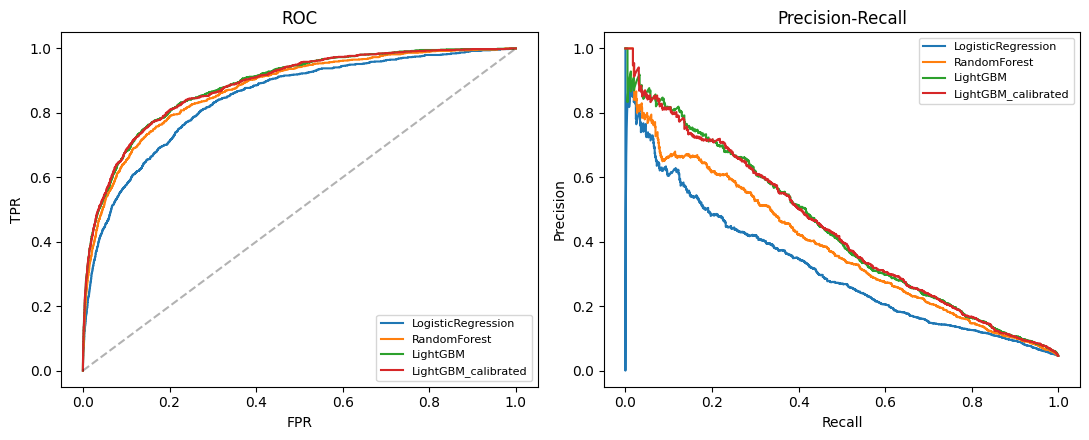

In [35]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name in models:
    p = curves[name][2]
    fpr, tpr, _ = roc_curve(y_test, p)
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(rec, prec, label=name)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


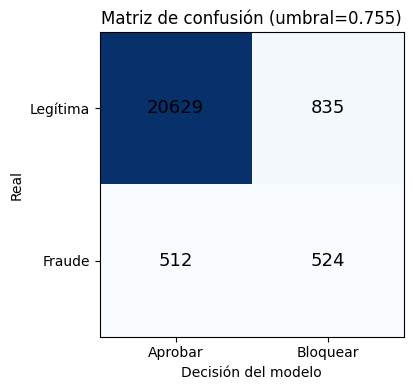

              precision    recall  f1-score   support

    Legítima       0.98      0.96      0.97     21464
      Fraude       0.39      0.51      0.44      1036

    accuracy                           0.94     22500
   macro avg       0.68      0.73      0.70     22500
weighted avg       0.95      0.94      0.94     22500



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

pred_best = (p_test_best >= best_thr).astype(int)  # 1 = bloquear
cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)
plt.xticks([0, 1], ["Aprobar", "Bloquear"]); plt.yticks([0, 1], ["Legítima", "Fraude"])
plt.xlabel("Decisión del modelo"); plt.ylabel("Real")
plt.title(f"Matriz de confusión (umbral={best_thr:.3f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_best, target_names=["Legítima", "Fraude"]))


Notar que, al umbral óptimo de negocio, el modelo bloquea bastantes
transacciones legítimas (precisión de la clase fraude ~0.35-0.40). Esto es
**esperado y correcto**: el umbral no busca maximizar precisión ni recall,
busca maximizar ganancia — y como el costo de dejar pasar un fraude (100%
del monto) es 4 veces el beneficio de aprobar una transacción buena (25%),
conviene ser bastante conservador (bloquear ante la duda) aunque eso
implique sacrificar precisión.

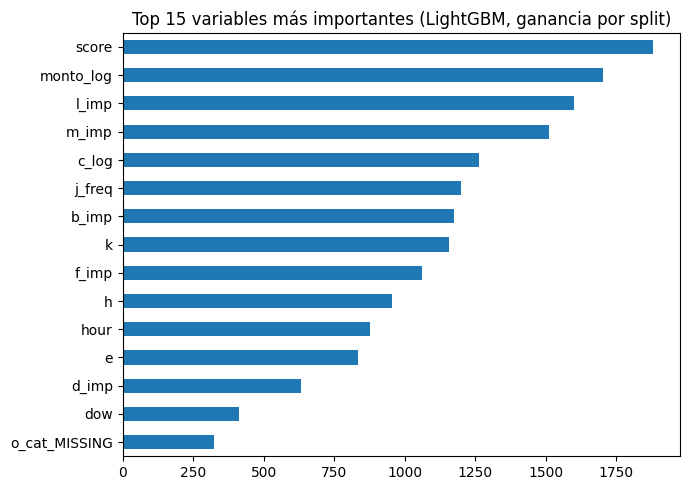

In [37]:
importances = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(7, 5))
importances.iloc[::-1].plot(kind="barh")
plt.title("Top 15 variables más importantes (LightGBM, ganancia por split)")
plt.tight_layout()
plt.show()


**Variables más relevantes:** `score` (el score de riesgo ya existente en
el sistema) sigue siendo la señal más fuerte — lo cual es razonable, ya que
resume mucha lógica de negocio previa — seguido por variables de
comportamiento (`l`, `m`, `b`), el monto de la transacción, y `j_freq`
(qué tan común es la categoría de producto). El indicador `o_missing`
también aporta, confirmando la hipótesis del EDA.

## 8. Conclusión de esta sección

- El modelo **LightGBM calibrado**, con umbral de decisión ≈0.20 (que
  coincide con el umbral analítico derivado de la economía del problema),
  genera un **~25% más de ganancia neta** que la política actual implícita
  de "aprobar todo" (o cualquier política que no discrimine fraude), medido
  sobre datos que el modelo nunca vio, del período más reciente disponible.
- El paso de calibrar las probabilidades no es un detalle menor: sin
  calibración, aplicar directamente la fórmula económica del umbral
  (0.20) da resultados peores que el baseline ingenuo.
- El resto del informe (hipótesis, conclusiones de negocio, y las preguntas
  sobre performance en producción, causas de degradación y pasos de
  deployment) se desarrolla en el documento separado.
